In [15]:
""" Imports and loading the data"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
csv_path = PROJECT_ROOT / "archive" / "neo_v2.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.dtypes

print("Missing values per column:")
df.isnull().sum()

Shape: (90836, 10)
Missing values per column:


id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

In [16]:
""" Dropping non-informative columns"""
print("Unique values in orbiting_body:", df["orbiting_body"].unique())
print("Unique values in sentry_object:", df["sentry_object"].unique())

drop_cols = ["id", "name"]
if df["orbiting_body"].nunique() == 1:
    drop_cols.append("orbiting_body")

df = df.drop(columns=drop_cols)
print("Dropped columns:", drop_cols)
print("Remaining columns:", list(df.columns))

Unique values in orbiting_body: <StringArray>
['Earth']
Length: 1, dtype: str
Unique values in sentry_object: [False]
Dropped columns: ['id', 'name', 'orbiting_body']
Remaining columns: ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'sentry_object', 'absolute_magnitude', 'hazardous']


In [17]:
""" Checking "ratio" between hazardous and non-hazardous"""
print(df["hazardous"].value_counts())
print()
print(df["hazardous"].value_counts(normalize=True) * 100)

hazardous
False    81996
True      8840
Name: count, dtype: int64

hazardous
False    90.268176
True      9.731824
Name: proportion, dtype: float64


In [18]:
""" Summar statistics """
numeric_cols = ["est_diameter_min", "est_diameter_max",
                 "relative_velocity", "miss_distance", "absolute_magnitude"]
df[numeric_cols].describe()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


In [19]:
""" Correlation """
df["hazardous_int"] = df["hazardous"].astype(int)
df[numeric_cols + ["hazardous_int"]].corr()["hazardous_int"]

est_diameter_min      0.183363
est_diameter_max      0.183363
relative_velocity     0.191185
miss_distance         0.042302
absolute_magnitude   -0.365267
hazardous_int         1.000000
Name: hazardous_int, dtype: float64

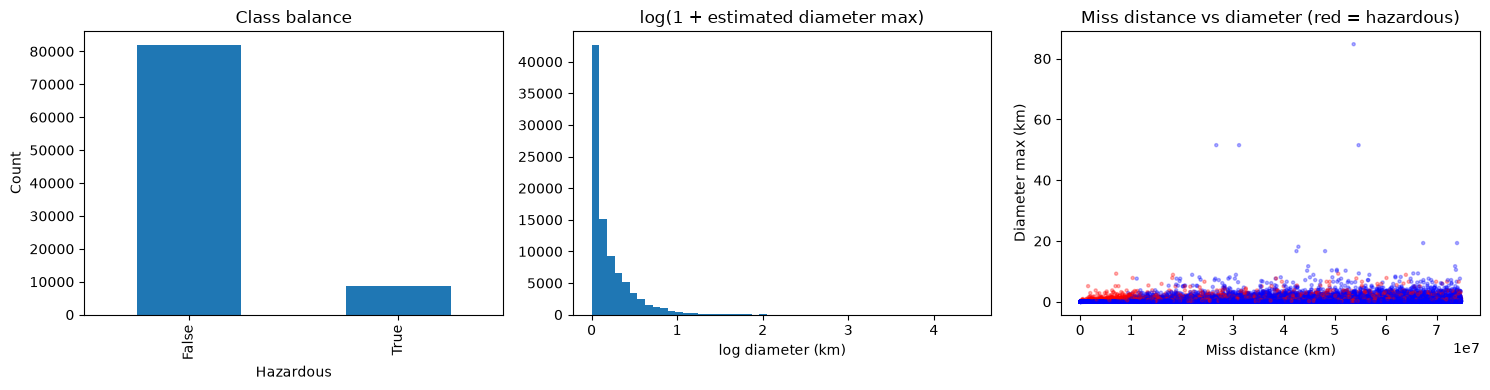

In [ ]:
""" Visulaization """
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class balance bar chart
df["hazardous"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Class balance")
axes[0].set_xlabel("Hazardous")
axes[0].set_ylabel("Count")

# Distribution of diameter (log scale, since it's skewed)
axes[1].hist(np.log1p(df["est_diameter_max"]), bins=50)
axes[1].set_title("log(1 + estimated diameter max)")
axes[1].set_xlabel("log diameter (km)")

# Miss distance vs diameter, colored by hazard status
colors = df["hazardous"].map({True: "red", False: "blue"})
axes[2].scatter(df["miss_distance"], df["est_diameter_max"],
                 c=colors, alpha=0.3, s=5)
axes[2].set_title("Miss distance vs diameter (red = hazardous)")
axes[2].set_xlabel("Miss distance (km)")
axes[2].set_ylabel("Diameter max (km)")

plt.tight_layout()
plt.show()